In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

FILE_PATH = "決定版.csv"

# CSV読み込み
df = pd.read_csv(FILE_PATH, encoding="utf-8-sig")

print("データ行数:", len(df))
print("列数:", len(df.columns))
print("列名一覧:")
print(df.columns.tolist())

df.head()

データ行数: 7338
列数: 39
列名一覧:
['日付', '球団', '対戦相手', '打者名', '打順', 'イニング', '表裏', 'イニング内打席番号', '自チーム打席前得点', '相手チーム打席前得点', '打席前点差', '打席前アウト数', '打席前走者状況コード', '打席前一塁走者', '打席前二塁走者', '打席前三塁走者', '打席前状況コード', '打席結果', 'この打席得点数', '打点', '自チーム打席後得点', '相手チーム打席後得点', '打席後点差', '打席後アウト数', '打席後走者状況コード', '打席後一塁走者', '打席後二塁走者', '打席後三塁走者', '打席後状況コード', '得点圏フラグ', '打者走者進塁先', '打席前RE', '打席後RE', 'RE24', '打席前WE', '打席後WE', 'WPA', 'WEサンプル数_前', 'WEサンプル数_後']


,日付,球団,対戦相手,打者名,打順,イニング,表裏,イニング内打席番号,自チーム打席前得点,相手チーム打席前得点,...,得点圏フラグ,打者走者進塁先,打席前RE,打席後RE,RE24,打席前WE,打席後WE,WPA,WEサンプル数_前,WEサンプル数_後
0,2025-03-28,巨人,ヤクルト,岡本 和真,4,1,裏,4,0,0,...,1,0,1.016,0.431,-0.585,0.714286,0.521739,-0.192547,14,23
1,2025-03-28,ヤクルト,巨人,サンタナ,4,2,表,1,0,0,...,0,0,0.365,0.189,-0.176,0.463250,0.432540,-0.030710,517,378
2,2025-03-28,巨人,ヤクルト,岡本 和真,4,3,裏,2,0,0,...,0,0,0.189,0.074,-0.115,0.526906,0.505525,-0.021381,223,181
3,2025-03-28,ヤクルト,巨人,サンタナ,4,5,表,1,0,0,...,0,1,0.365,0.675,0.310,0.479167,0.632353,0.153186,192,34
4,2025-03-28,ヤクルト,巨人,サンタナ,4,6,表,1,4,0,...,0,4,0.365,0.365,1.000,0.871795,0.875000,0.003205,39,16


In [19]:
# 列名を確認する
print(df.columns.tolist())

# 分析に使いそうな列を探す
keywords = ["打者", "球団", "打点", "RE24", "WPA", "本塁打", "HR"]

for keyword in keywords:
    print(f"\n【{keyword}を含む列】")
    print([col for col in df.columns if keyword in str(col)])

['日付', '球団', '対戦相手', '打者名', '打順', 'イニング', '表裏', 'イニング内打席番号', '自チーム打席前得点', '相手チーム打席前得点', '打席前点差', '打席前アウト数', '打席前走者状況コード', '打席前一塁走者', '打席前二塁走者', '打席前三塁走者', '打席前状況コード', '打席結果', 'この打席得点数', '打点', '自チーム打席後得点', '相手チーム打席後得点', '打席後点差', '打席後アウト数', '打席後走者状況コード', '打席後一塁走者', '打席後二塁走者', '打席後三塁走者', '打席後状況コード', '得点圏フラグ', '打者走者進塁先', '打席前RE', '打席後RE', 'RE24', '打席前WE', '打席後WE', 'WPA', 'WEサンプル数_前', 'WEサンプル数_後']

【打者を含む列】
['打者名', '打者走者進塁先']

【球団を含む列】
['球団']

【打点を含む列】
['打点']

【RE24を含む列】
['RE24']

【WPAを含む列】
['WPA']

【本塁打を含む列】
[]

【HRを含む列】
[]


In [20]:
# 実際の列名に合わせて設定してください
batter_col = "打者名"
team_col = "球団"
rbi_col = "打点"
re24_col = "RE24"
wpa_col = "WPA"

# HR列があるか自動で探す
hr_candidates = [
    col for col in df.columns
    if "本塁打" in str(col) or str(col).upper() == "HR"
]

hr_col = hr_candidates[0] if len(hr_candidates) > 0 else None

print("打者列:", batter_col)
print("球団列:", team_col)
print("打点列:", rbi_col)
print("RE24列:", re24_col)
print("WPA列:", wpa_col)
print("HR列:", hr_col)

打者列: 打者名
球団列: 球団
打点列: 打点
RE24列: RE24
WPA列: WPA
HR列: None


In [21]:
# 数値として使う列
numeric_cols = [rbi_col, re24_col, wpa_col]

if hr_col is not None:
    numeric_cols.append(hr_col)

# 数値型に変換
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 欠損確認
print("数値列の欠損数")
print(df[numeric_cols].isna().sum())

数値列の欠損数
打点      0
RE24    0
WPA     0
dtype: int64


In [22]:
summary = (
    df.groupby([team_col, batter_col])
    .agg(
        PA=(batter_col, "count"),
        打点合計=(rbi_col, "sum"),
        RE24合計=(re24_col, "sum"),
        WPA合計=(wpa_col, "sum")
    )
    .reset_index()
)

# HR列がある場合だけ追加
if hr_col is not None:
    hr_summary = (
        df.groupby([team_col, batter_col])[hr_col]
        .sum()
        .reset_index()
        .rename(columns={hr_col: "HR合計"})
    )
    summary = summary.merge(hr_summary, on=[team_col, batter_col], how="left")

# PAが多い順に並べる
summary = summary.sort_values("PA", ascending=False)

summary.head(20)

,球団,打者名,PA,打点合計,RE24合計,WPA合計
156,阪神,佐藤 輝明,544,91,47.723,3.238965
149,西武,ネビン,491,54,21.654,0.468037
84,中日,細川 成也,313,43,19.930,3.654191
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737
93,巨人,岡本 和真,280,49,28.686,4.366410
44,ヤクルト,オスナ,273,30,3.214,0.736590
110,広島,末包 昇大,267,40,10.932,-0.075041
10,DeNA,牧 秀悟,243,27,8.321,5.049012
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346


In [23]:
summary_100 = summary[summary["PA"] >= 100].copy()

print("PA100以上の選手数:", len(summary_100))

summary_100.sort_values("PA", ascending=False).head(20)

PA100以上の選手数: 25


,球団,打者名,PA,打点合計,RE24合計,WPA合計
156,阪神,佐藤 輝明,544,91,47.723,3.238965
149,西武,ネビン,491,54,21.654,0.468037
84,中日,細川 成也,313,43,19.930,3.654191
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737
93,巨人,岡本 和真,280,49,28.686,4.366410
44,ヤクルト,オスナ,273,30,3.214,0.736590
110,広島,末包 昇大,267,40,10.932,-0.075041
10,DeNA,牧 秀悟,243,27,8.321,5.049012
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346


In [24]:
rbi_rank = summary_100.sort_values("打点合計", ascending=False)

rbi_rank[
    [team_col, batter_col, "PA", "打点合計", "RE24合計", "WPA合計"]
].head(10)

,球団,打者名,PA,打点合計,RE24合計,WPA合計
156,阪神,佐藤 輝明,544,91,47.723,3.238965
149,西武,ネビン,491,54,21.654,0.468037
93,巨人,岡本 和真,280,49,28.686,4.366410
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346
84,中日,細川 成也,313,43,19.930,3.654191
110,広島,末包 昇大,267,40,10.932,-0.075041
113,日本ハム,レイエス,157,40,25.210,4.825634
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737
44,ヤクルト,オスナ,273,30,3.214,0.736590
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217


In [25]:
re24_rank = summary_100.sort_values("RE24合計", ascending=False)

re24_rank[
    [team_col, batter_col, "PA", "打点合計", "RE24合計", "WPA合計"]
].head(10)

,球団,打者名,PA,打点合計,RE24合計,WPA合計
156,阪神,佐藤 輝明,544,91,47.723,3.238965
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346
93,巨人,岡本 和真,280,49,28.686,4.366410
113,日本ハム,レイエス,157,40,25.210,4.825634
149,西武,ネビン,491,54,21.654,0.468037
84,中日,細川 成也,313,43,19.930,3.654191
110,広島,末包 昇大,267,40,10.932,-0.075041
86,巨人,キャベッジ,157,26,10.538,1.219419
133,楽天,ボイト,154,17,10.230,0.418691
43,ソフトバンク,近藤 健介,128,18,9.484,1.482278


In [26]:
wpa_rank = summary_100.sort_values("WPA合計", ascending=False)

wpa_rank[
    [team_col, batter_col, "PA", "打点合計", "RE24合計", "WPA合計"]
].head(10)

,球団,打者名,PA,打点合計,RE24合計,WPA合計
10,DeNA,牧 秀悟,243,27,8.321,5.049012
113,日本ハム,レイエス,157,40,25.210,4.825634
93,巨人,岡本 和真,280,49,28.686,4.366410
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346
84,中日,細川 成也,313,43,19.930,3.654191
156,阪神,佐藤 輝明,544,91,47.723,3.238965
102,広島,モンテロ,180,18,-3.287,1.595811
43,ソフトバンク,近藤 健介,128,18,9.484,1.482278
86,巨人,キャベッジ,157,26,10.538,1.219419
0,DeNA,オースティン,210,26,5.493,1.218329


In [27]:
corr_cols = ["打点合計", "RE24合計", "WPA合計"]

if "HR合計" in summary_100.columns:
    corr_cols.append("HR合計")

corr_matrix = summary_100[corr_cols].corr()

corr_matrix

,打点合計,RE24合計,WPA合計
打点合計,1.000000,0.856712,0.579202
RE24合計,0.856712,1.000000,0.700414
WPA合計,0.579202,0.700414,1.000000


In [28]:
print("打点 × RE24:", summary_100["打点合計"].corr(summary_100["RE24合計"]))
print("打点 × WPA:", summary_100["打点合計"].corr(summary_100["WPA合計"]))
print("RE24 × WPA:", summary_100["RE24合計"].corr(summary_100["WPA合計"]))

if "HR合計" in summary_100.columns:
    print("HR × RE24:", summary_100["HR合計"].corr(summary_100["RE24合計"]))
    print("HR × WPA:", summary_100["HR合計"].corr(summary_100["WPA合計"]))

打点 × RE24: 0.8567123924194945
打点 × WPA: 0.5792017453439605
RE24 × WPA: 0.7004142493248574


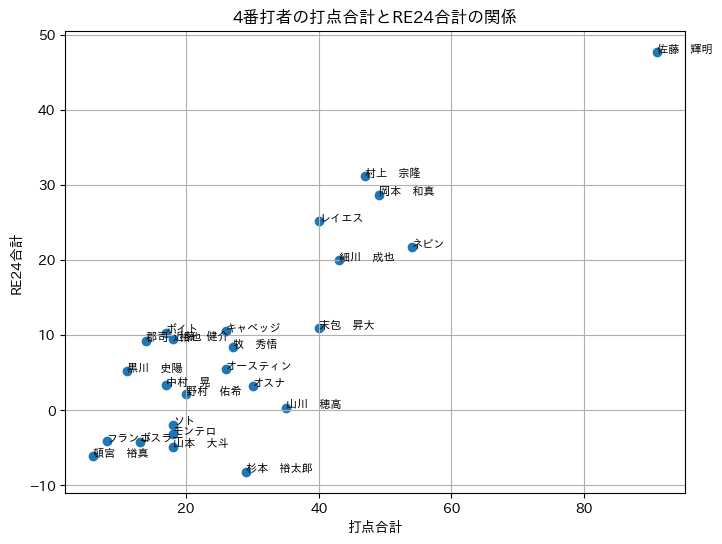

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(summary_100["打点合計"], summary_100["RE24合計"])

for _, row in summary_100.iterrows():
    plt.text(
        row["打点合計"],
        row["RE24合計"],
        row[batter_col],
        fontsize=8
    )

plt.xlabel("打点合計")
plt.ylabel("RE24合計")
plt.title("4番打者の打点合計とRE24合計の関係")
plt.grid(True)
plt.show()

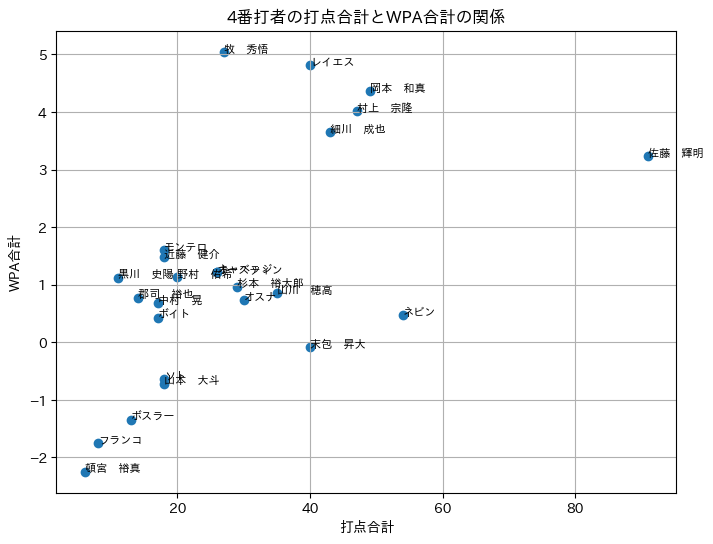

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(summary_100["打点合計"], summary_100["WPA合計"])

for _, row in summary_100.iterrows():
    plt.text(
        row["打点合計"],
        row["WPA合計"],
        row[batter_col],
        fontsize=8
    )

plt.xlabel("打点合計")
plt.ylabel("WPA合計")
plt.title("4番打者の打点合計とWPA合計の関係")
plt.grid(True)
plt.show()

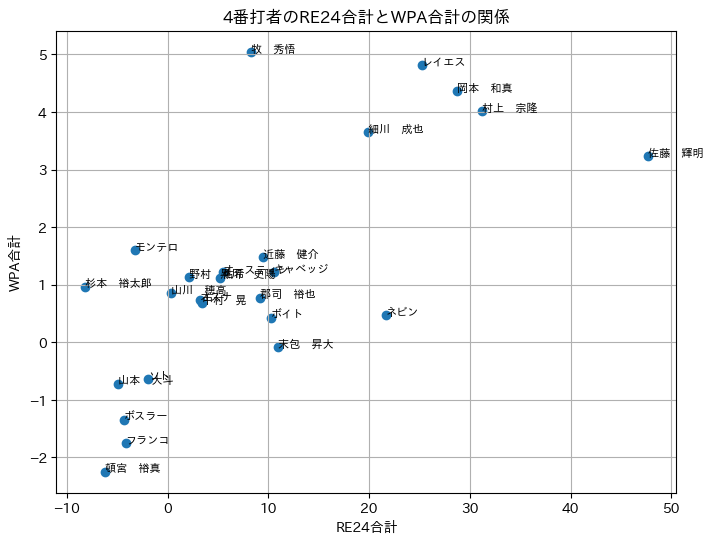

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(summary_100["RE24合計"], summary_100["WPA合計"])

for _, row in summary_100.iterrows():
    plt.text(
        row["RE24合計"],
        row["WPA合計"],
        row[batter_col],
        fontsize=8
    )

plt.xlabel("RE24合計")
plt.ylabel("WPA合計")
plt.title("4番打者のRE24合計とWPA合計の関係")
plt.grid(True)
plt.show()

In [32]:
rank_df = summary_100.copy()

rank_df["打点順位"] = rank_df["打点合計"].rank(ascending=False, method="min")
rank_df["RE24順位"] = rank_df["RE24合計"].rank(ascending=False, method="min")
rank_df["WPA順位"] = rank_df["WPA合計"].rank(ascending=False, method="min")

# 数字が大きいほど、打点順位よりWPA順位が良い
rank_df["WPA評価上昇"] = rank_df["打点順位"] - rank_df["WPA順位"]

rank_df = rank_df.sort_values("WPA評価上昇", ascending=False)

rank_df[
    [team_col, batter_col, "PA", "打点合計", "RE24合計", "WPA合計", "打点順位", "WPA順位", "WPA評価上昇"]
].head(10)

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点順位,WPA順位,WPA評価上昇
147,楽天,黒川 史陽,105,11,5.203,1.124762,23.0,12.0,11.0
10,DeNA,牧 秀悟,243,27,8.321,5.049012,11.0,1.0,10.0
102,広島,モンテロ,180,18,-3.287,1.595811,15.0,7.0,8.0
43,ソフトバンク,近藤 健介,128,18,9.484,1.482278,15.0,8.0,7.0
129,日本ハム,郡司 裕也,148,14,9.203,0.776498,21.0,15.0,6.0
113,日本ハム,レイエス,157,40,25.210,4.825634,6.0,2.0,4.0
130,日本ハム,野村 佑希,218,20,2.118,1.132902,14.0,11.0,3.0
86,巨人,キャベッジ,157,26,10.538,1.219419,12.0,9.0,3.0
0,DeNA,オースティン,210,26,5.493,1.218329,12.0,10.0,2.0
32,ソフトバンク,中村 晃,171,17,3.365,0.678367,19.0,17.0,2.0


In [33]:
rank_df_low = rank_df.sort_values("WPA評価上昇", ascending=True)

rank_df_low[
    [team_col, batter_col, "PA", "打点合計", "RE24合計", "WPA合計", "打点順位", "WPA順位", "WPA評価上昇"]
].head(10)

,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点順位,WPA順位,WPA評価上昇
149,西武,ネビン,491,54,21.654,0.468037,2.0,18.0,-16.0
110,広島,末包 昇大,267,40,10.932,-0.075041,6.0,20.0,-14.0
66,ロッテ,山本 大斗,201,18,-4.906,-0.718523,15.0,22.0,-7.0
44,ヤクルト,オスナ,273,30,3.214,0.736590,9.0,16.0,-7.0
34,ソフトバンク,山川 穂高,289,35,0.287,0.849737,8.0,14.0,-6.0
59,ロッテ,ソト,179,18,-1.956,-0.638764,15.0,21.0,-6.0
156,阪神,佐藤 輝明,544,91,47.723,3.238965,1.0,6.0,-5.0
22,オリックス,杉本 裕太郎,308,29,-8.236,0.965217,10.0,13.0,-3.0
75,中日,ボスラー,150,13,-4.350,-1.352659,22.0,23.0,-1.0
53,ヤクルト,村上 宗隆,222,47,31.171,4.020346,4.0,4.0,0.0
